In [21]:
import sys
sys.path.append("/project/src")

In [22]:
# Helper imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split
from sksurv.util import Surv

from rsfmodel import RandomSurvivalForest
from preprocessing import (
    BaseDatasetPreprocessor,
    N_IMPORTANT_FEATURES,
    split_features_target,
    low_missingness_complete_case_analysis,
    concat_features_target,
    decode_preprocessed_feature_name,
    SURVIVAL_EVENT_COL,
    SURVIVAL_TIME_COL,
)

import joblib
import wandb

In [23]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_data_csv = "/content/drive/MyDrive/bachelor/nacc_data_2025.csv"
else:
    nacc_data_csv = "./data/nacc_data_2025.csv"

In [24]:
nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')

/tmp/ipykernel_1957/2070981678.py:1: DtypeWarning: Columns (4,8,10,21,25,27,28,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,138,149,190,193,195,201,203,205,207,209,211,215,217,219,221,223,225,227,229,231,233,235,237,239,241,245,370,372,374,405,418,425,465,545,576,601,636,652,669,672,689,700,706,758,760,762,763,769,792,805,813,814,815,816,826,848,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')


In [25]:
nacc_raw.head()

,NACCREFR,SEX,HISPANIC,HISPOR,HISPORX,RACE,RACEX,RACESEC,RACESECX,RACETER,...,NPCOTH1,NPOTH1X,NPPOTH2,NPCOTH2,NPOTH2X,NPPOTH3,NPCOTH3,NPOTH3X,EVENT_MCI,TIME
0,1.0,1,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,8.487
1,NaN,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.035
2,2.0,2,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.474
3,1.0,2,0.0,NaN,NaN,1.0,NaN,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.025
4,NaN,1,0.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,2.012


In [26]:
print(f"shape {nacc_raw.shape}")

shape (17477, 857)


In [27]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_preprocessed_train_data_csv = "/content/drive/MyDrive/bachelor/nacc_train_tunning_preprocessed.csv"
    nacc_train_raw_csv = "/content/drive/MyDrive/bachelor/nacc_train.csv"
else:
    nacc_preprocessed_train_data_csv = "./data/nacc_train_tunning_preprocessed.csv"
    nacc_train_raw_csv = "./data/nacc_train.csv"

In [28]:
nacc_preprocessed_train_df = pd.read_csv(nacc_preprocessed_train_data_csv, delimiter=',')
nacc_train_raw = pd.read_csv(nacc_train_raw_csv, delimiter=',')

/tmp/ipykernel_1957/1728453696.py:2: DtypeWarning: Columns (4,10,21,27,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,190,193,205,209,211,215,217,219,221,223,225,227,229,231,233,235,237,239,241,245,370,372,374,394,405,418,465,545,576,601,669,672,706,758,760,763,792,804,805,813,814,815,816,826,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_train_raw = pd.read_csv(nacc_train_raw_csv, delimiter=',')


In [29]:
nacc_preprocessed_train_df.shape

(6176, 350)

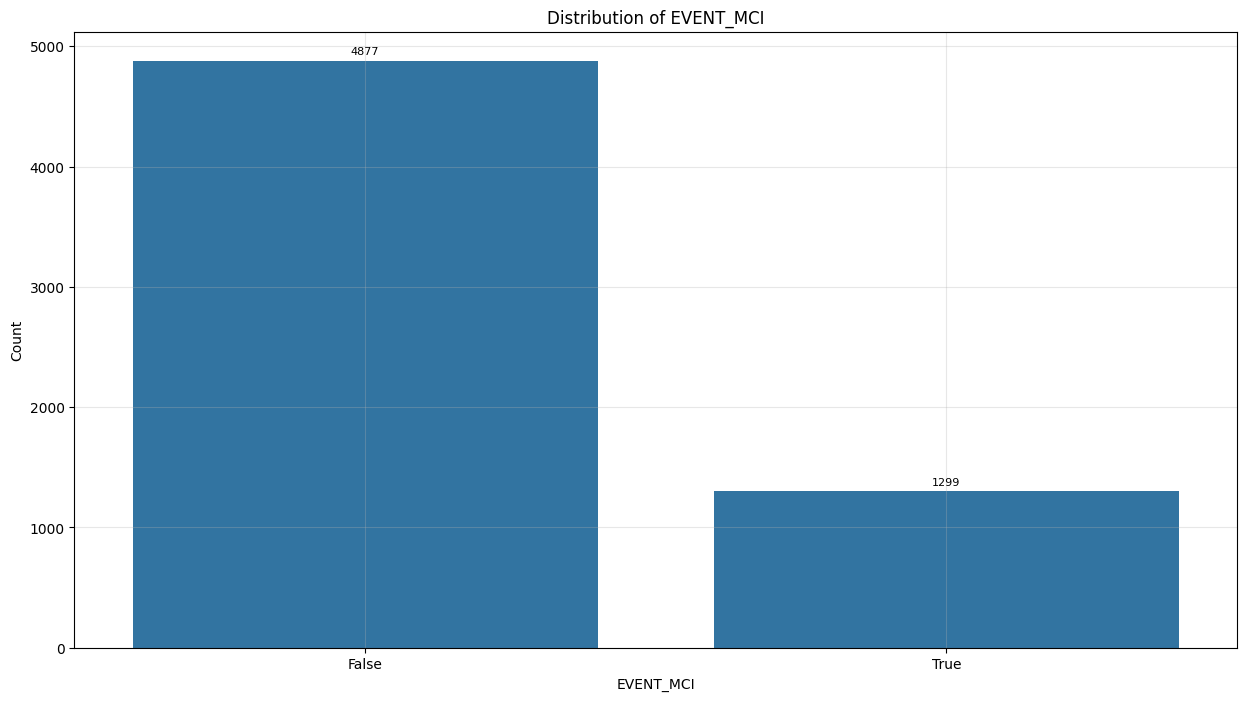

In [30]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=nacc_preprocessed_train_df['EVENT_MCI'].value_counts().index, y=nacc_preprocessed_train_df['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
nacc_preprocessed_train_df['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
False    0.78967
True     0.21033
Name: proportion, dtype: float64

According to EPV rule we need to provide as least 10 records per variable for the analysis and prediction to be reliable. After analysing the number of events during the eda - the number of features cannot extend 237 values (The 1 place is remained for the missing indicator, that should definetelly be in the final dataset)

## Feature selection

In [32]:
def rsf_vimp_feature_selection(x_data, y_data, n_features, rsf_params):
    rsf = RandomSurvivalForest(
        num_trees       = rsf_params["num_trees"],
        mtry            = rsf_params["mtry"],
        min_node_size   = rsf_params["min_node_size"],
        replace         = rsf_params["replace"],
        sample_fraction = rsf_params["sample_fraction"],
        importance      = "permutation",
        compute_weights = True,
        OOB_score       = True,
    )
    rsf.fit(x_data, y_data)
    vimp_importance = rsf.get_importance()

    print("rsf.oob_score_():", rsf.oob_score_())
    return vimp_importance.head(n_features).index.tolist(), vimp_importance.head(n_features)


# Dataset preprocessor class

In [33]:
# class AdvancedDatasetPreprocessor():
#     def __init__(self, n_important_features=N_IMPORTANT_FEATURES, best_rsf_vimp_parameters=None):
#         super().__init__()
#         self.n_important_features     = n_important_features
#         self._selected_features       = None
#         self._train_categorical_cols  = None
#         self._train_continuous_cols   = None
#         self.best_parameters          = best_rsf_vimp_parameters

#     def fit(self, df):
#         self._select_features
  
#     def fit_transform(self, df):
#         """
#           Fit the full pipeline on df and return (X, y).
#           Extends the base fit with feature selection and subset re-fitting.

#           Steps
#           -----
#           1–3. Base preprocessing (see :class:`BaseDatasetPreprocessor`).
#           4.   RSF-VIMP feature selection → select top-N features.
#           5.   Complete-case analysis restricted to the selected feature subset.
#           6.   Re-fit + apply the pipeline on the reduced subset.
#         """
#         X_preprocessed, y_full = super().fit_transform(df)

#         # Snapshot column roles before they are overwritten by subset re-fit
#         self._train_categorical_cols  = list(self._categorical_cols)
#         self._train_continuous_cols   = list(self._continuous_cols)
#         self._selected_features       = self._select_features(X_preprocessed, y_full)
#         self._fitted_columns          = list(X_preprocessed.columns)

#         X_final, y_final = self._build_subset_pipeline(
#             selected_features=self._selected_features,
#             categorical_cols=self._train_categorical_cols,
#             continuous_cols=self._train_continuous_cols,
#             pipeline_mode="fit_transform",
#         )
#         return X_final, y_final

#     def transform(self, df):
#         """
#           Apply the already-fitted full pipeline to df and return (X, y).
#         """
#         self._assert_fully_fitted()
#         self._apply_structural_cleanup(df)

#         X_final, y_final = self._build_subset_pipeline(
#             selected_features=self._selected_features,
#             categorical_cols=self._train_categorical_cols,
#             continuous_cols=self._train_continuous_cols,
#             pipeline_mode="transform",
#         )
#         return X_final, y_final

#     def _select_features(self, X, y):
#         """
#           Select subset of features to reduce the dimensionality of the dataset
#           Applicable only on training data.
#         """
#         selected = rsf_vimp_feature_selection(
#             X, y, n_features=self.n_important_features, parameters=self.best_parameters
#         )
#         if MANDATORY_FEATURE not in selected:
#             selected.append(MANDATORY_FEATURE)
#         return selected

#     def _build_subset_pipeline(self, selected_features, categorical_cols, continuous_cols, pipeline_mode):
#         """
#           Reverse-map selected preprocessed feature names to raw columns, apply
#           complete-case analysis on the subset, and re-run the pipeline.
#         """
#         raw_subset = select_features_subset(
#             self._cleaned_df,
#             selected_features,
#             categorical_cols,
#             continuous_cols,
#         )

#         subset_low_missing = keep_available(self._low_missing_cols, raw_subset.columns)
#         subset_cleaned     = low_missingness_complete_case_analysis(raw_subset, subset_low_missing)
#         X_subset, y_subset = split_features_target(subset_cleaned)

#         if pipeline_mode == "fit_transform":
#             X_preprocessed = self._fit_transform_pipeline(X_subset)
#         else:
#             X_preprocessed = self._transform_pipeline(X_subset)

#         final_features = keep_available(selected_features, X_preprocessed.columns)
#         return X_preprocessed[final_features], y_subset

#     def _assert_fully_fitted(self):
#         if self._pipeline is None or self._selected_features is None:
#             raise RuntimeError(
#                 "Preprocessor is not fully fitted. Call fit_transform() on training data first."
#             )

# Init wandb

In [34]:
# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="semariik",
    # Set the wandb project where this run will be logged.
    project="survival-analysis-mci",
)

# Final dataset preprocessing

## Fit dataset preprocessor on train data

In [35]:
best_parameters = joblib.load("joblib-storage/rsf_vimp_best_params_processed.joblib")

In [36]:
best_parameters

{'num_trees': np.int64(350),
 'mtry': 'sqrt',
 'min_node_size': 67,
 'replace': True,
 'sample_fraction': np.float64(0.5802062339524041)}

In [37]:
X_train_base_preprocessed, y_train_base_preprocessed = split_features_target(nacc_preprocessed_train_df)

In [38]:
selected_features_columns, selected_features_df = rsf_vimp_feature_selection(
    X_train_base_preprocessed, y_train_base_preprocessed, n_features=N_IMPORTANT_FEATURES, rsf_params=best_parameters
)

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  




Running Random Survival Forest with parameters: num_trees=350, min_node_size=67, mtry=sqrt, splitrule='C', importance='permutation', compute_weights=True, replace=True, sample_fraction=0.5802062339524041
Growing trees.. Progress: 9%. Estimated remaining time: 5 minutes, 19 seconds.
Growing trees.. Progress: 19%. Estimated remaining time: 4 minutes, 31 seconds.
Growing trees.. Progress: 28%. Estimated remaining time: 3 minutes, 58 seconds.
Growing trees.. Progress: 38%. Estimated remaining time: 3 minutes, 25 seconds.
Growing trees.. Progress: 48%. Estimated remaining time: 2 minutes, 49 seconds.
Growing trees.. Progress: 58%. Estimated remaining time: 2 minutes, 16 seconds.
Growing trees.. Progress: 68%. Estimated remaining time: 1 minute, 45 seconds.
Growing trees.. Progress: 78%. Estimated remaining time: 1 minute, 12 seconds.
Growing trees.. Progress: 87%. Estimated remaining time: 40 seconds.
Growing trees.. Progress: 97%. Estimated remaining time: 11 seconds.
Computing permutati

In [39]:
selected_features_df

,importances_mean,importances_mean_abs
continuous__NACCAGEB,0.015980,0.015980
continuous__TRAILB,0.015112,0.015112
categorical__NACCNOVS_0,0.013205,0.013205
categorical__NACCNOVS_1,0.012302,0.012302
continuous__VEG,0.010767,0.010767
...,...,...
categorical__NACCAANX_0.0,-0.000011,0.000011
categorical__STOVE_0.0,0.000010,0.000010
"categorical__MARISTAT_MARISTAT_6.0, 4.0",-0.000010,0.000010
categorical__EMPTY_EMPTY_1.0,-0.000010,0.000010


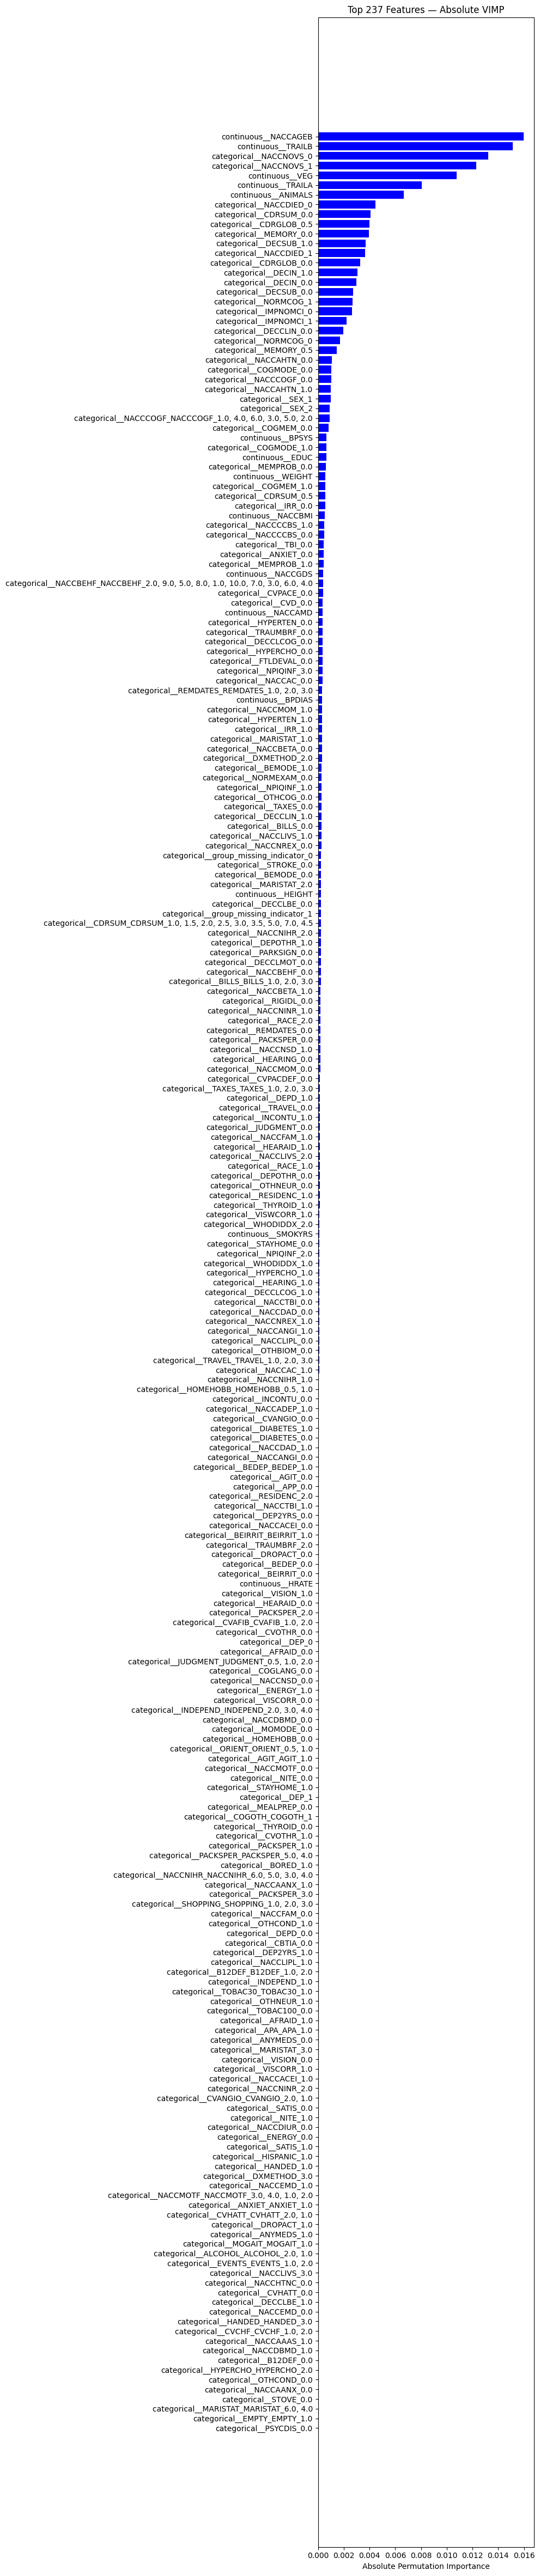

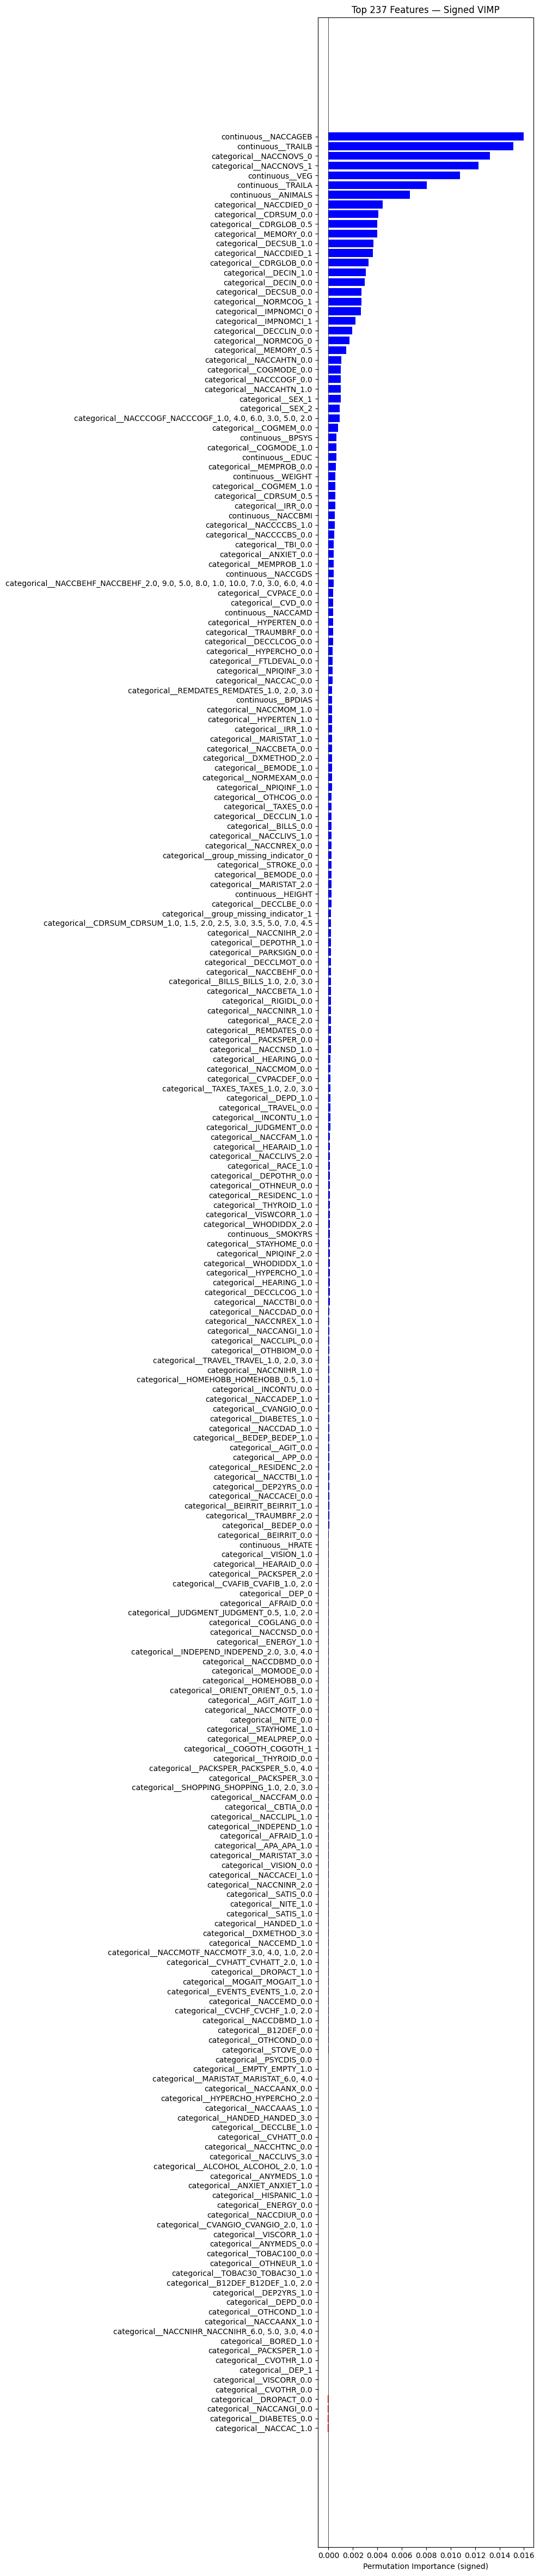

In [40]:
# Absolute importance — top features
fig_abs, ax_abs = plt.subplots(figsize=(10, max(6, len(selected_features_df) * 0.2)))
sorted_abs = selected_features_df.sort_values("importances_mean_abs", ascending=True)
ax_abs.barh(sorted_abs.index, sorted_abs["importances_mean_abs"], color="blue")
ax_abs.set_xlabel("Absolute Permutation Importance")
ax_abs.set_title(f"Top {len(selected_features_df)} Features — Absolute VIMP")
plt.tight_layout()
wandb.log({"vimp/absolute_importance": wandb.Image(fig_abs)})
plt.show()

# Signed importance — shows protective (negative) vs risk (positive) features
negative_features = selected_features_df[selected_features_df["importances_mean"] < 0]
if len(negative_features) > 0:
    fig_signed, ax_signed = plt.subplots(figsize=(10, max(6, len(selected_features_df) * 0.2)))
    sorted_signed = selected_features_df.sort_values("importances_mean", ascending=True)
    colors = ["red" if v < 0 else "blue" for v in sorted_signed["importances_mean"]]
    ax_signed.barh(sorted_signed.index, sorted_signed["importances_mean"], color=colors)
    ax_signed.axvline(x=0, color="black", linewidth=0.5)
    ax_signed.set_xlabel("Permutation Importance (signed)")
    ax_signed.set_title(f"Top {len(selected_features_df)} Features — Signed VIMP")
    plt.tight_layout()
    wandb.log({"vimp/signed_importance": wandb.Image(fig_signed)})
    plt.show()
else:
    print("No negative importance features found")

In [41]:
# Decode preprocessed feature names (e.g. 'continuous__HRATE') back to raw column names
# Use nacc_raw columns as the reference for matching
raw_columns = nacc_raw.columns.tolist()
raw_feature_names = list(set(
    decode_preprocessed_feature_name(f, raw_columns, raw_columns)
    for f in selected_features_columns
))

# Select only the raw features + target, then complete case analysis on each split
target_cols = [SURVIVAL_EVENT_COL, SURVIVAL_TIME_COL]
available_raw_features = [c for c in raw_feature_names if c in nacc_raw.columns]

reduced_train = nacc_train_raw[available_raw_features + target_cols]
train_df_reduced = low_missingness_complete_case_analysis(reduced_train)

Complete-case analysis on low-missing columns
Defining missingness


In [42]:
X_train_reduced, y_train_reduced = split_features_target(train_df_reduced)

In [43]:
train_df_reduced.to_csv("./data/nacc_train_reduced.csv", index=False)

# Asses final data

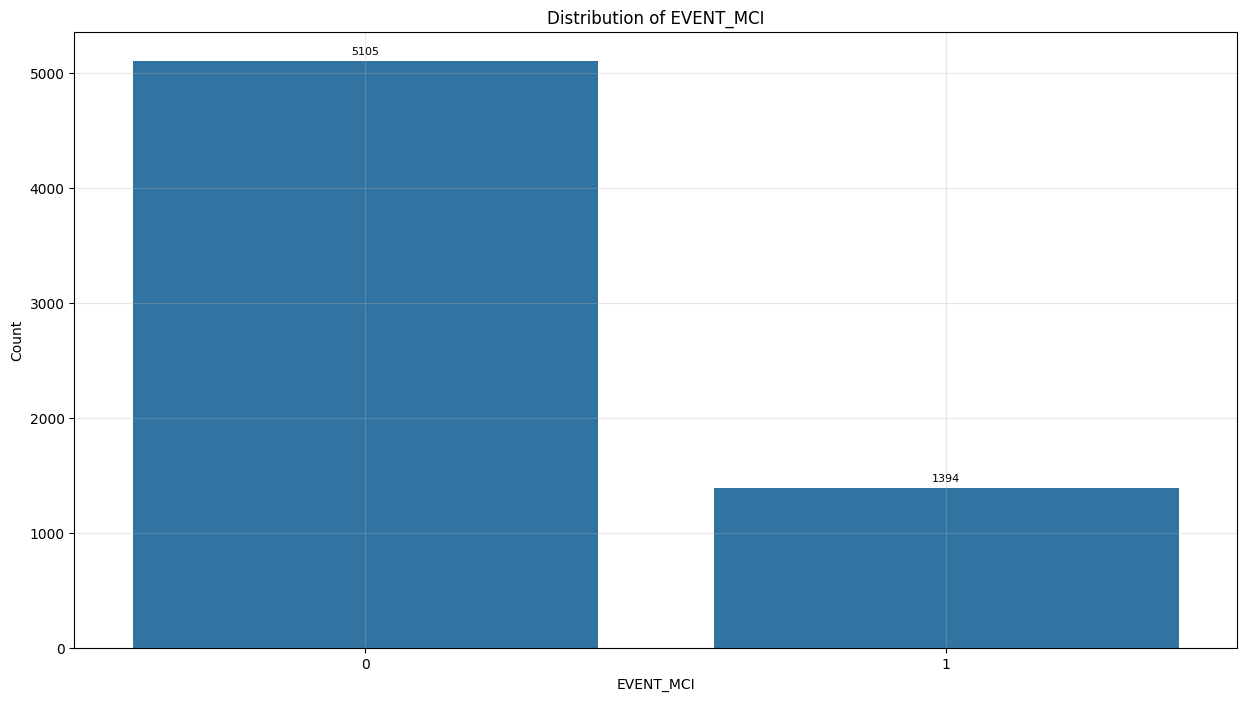

In [48]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=train_df_reduced['EVENT_MCI'].value_counts().index, y=train_df_reduced['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [49]:
train_df_reduced['EVENT_MCI'].value_counts(normalize=True)

EVENT_MCI
0    0.785505
1    0.214495
Name: proportion, dtype: float64